In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [3]:
## reading our closing files which is combined_weekly_dataset
## reading our predicted label regime_label_k
## reading our predicted supervised labels

## Read core files
regime_df = pd.read_parquet("regime_labeled_k_combine.parquet")
'''supervised_predictions = pd.read_parquet("/work/master_supervised_test_predictions.parquet")'''
supervised_predictions = pd.read_parquet("master_supervised_predictions.parquet")
combined_weekly = pd.read_parquet("combined_weekly_dataset.parquet")

# Make sure indexes are datetime + sorted
for df in [regime_df, supervised_predictions, combined_weekly]:
    df.index = pd.to_datetime(df.index)

regime_df = regime_df.sort_index()
supervised_predictions = supervised_predictions.sort_index()
combined_weekly = combined_weekly.sort_index()

print("regime_df shape:", regime_df.shape)
print("supervised_predictions shape:", supervised_predictions.shape)
print("combined_weekly shape:", combined_weekly.shape)

print("\nregime_df columns:")
print(regime_df.columns.tolist())

print("\nsupervised_predictions columns:")
print(supervised_predictions.columns.tolist())

print("\ncombined_weekly columns:")
print(combined_weekly.columns.tolist())

regime_df shape: (1055, 27)
supervised_predictions shape: (454, 34)
combined_weekly shape: (1633, 31)

regime_df columns:
['global_vol', 'vol_slope', 'vov', 'SP500_SPY_ret', 'NASDAQ100_QQQ_ret', 'DOW_JONES_ret', 'NASDAQ100_ret', 'NIKKEI_225_ret', 'SHANGHAI_COMPOSITE_ret', 'HANG_SENG_ret', 'TREASURY_BOND_TLT_ret', 'GOLD_GLD_ret', 'usd_index_ret', 'SPY_return', 'QQQ_return', 'SPY_vol_12', 'SPY_vol_4', 'SPY_momentum_12', 'VIX', 'VIX_change', 'TREASURY_10Y', 'TREASURY_2Y', 'yield_spread', 'regime', 'dataset_split', 'regime_name', 'regime_3class']

supervised_predictions columns:
['SPY_return', 'QQQ_return', 'SPY_momentum_12', 'VIX_change', 'SPY_vol_4', 'SPY_vol_12', 'yield_spread', 'SPY_return_lag1', 'SPY_return_lag2', 'SPY_return_lag3', 'SPY_return_lag4', 'SPY_return_lag5', 'VIX_change_lag1', 'VIX_change_lag2', 'VIX_change_lag3', 'VIX_change_lag4', 'VIX_change_lag5', 'yield_spread_lag1', 'yield_spread_lag2', 'yield_spread_lag3', 'yield_spread_lag4', 'yield_spread_lag5', 'current_regime', 

In [5]:
regime_df.index = pd.to_datetime(regime_df.index, errors="coerce")
supervised_predictions.index = pd.to_datetime(supervised_predictions.index, errors="coerce")
combined_weekly.index = pd.to_datetime(combined_weekly.index, errors="coerce")

regime_df = regime_df[~regime_df.index.isna()].copy()
supervised_predictions = supervised_predictions[~supervised_predictions.index.isna()].copy()
combined_weekly = combined_weekly[~combined_weekly.index.isna()].copy()

regime_df = regime_df[~regime_df.index.duplicated(keep="first")].sort_index()
supervised_predictions = supervised_predictions[~supervised_predictions.index.duplicated(keep="first")].sort_index()
combined_weekly = combined_weekly[~combined_weekly.index.duplicated(keep="first")].sort_index()

print("regime_df date range:", regime_df.index.min(), "to", regime_df.index.max())
print("supervised_predictions date range:", supervised_predictions.index.min(), "to", supervised_predictions.index.max())
print("combined_weekly date range:", combined_weekly.index.min(), "to", combined_weekly.index.max())

regime_df date range: 2004-11-26 00:00:00 to 2026-03-06 00:00:00
supervised_predictions date range: 2017-01-13 00:00:00 to 2026-02-13 00:00:00
combined_weekly date range: 1995-01-06 00:00:00 to 2026-04-17 00:00:00


In [9]:
# Keep only useful unsupervised columns
unsup_cols = [col for col in ["regime", "regime_3class", "regime_name", "dataset_split"] if col in regime_df.columns]
regime_subset = regime_df[unsup_cols].copy()

# Avoid duplicate dataset_split on join
sup_subset = supervised_predictions.copy()
if "dataset_split" in sup_subset.columns:
    sup_subset = sup_subset.drop(columns=["dataset_split"])

# Join unsupervised + supervised predictions first
full_pred = regime_subset.join(sup_subset, how="inner")

# Split validation vs test
pred_val = full_pred[full_pred["dataset_split"] == "val"].copy()
pred_test = full_pred[full_pred["dataset_split"] == "test"].copy()

# Add market data / returns source table
returns_df = combined_weekly.copy()

pred_val = pred_val.join(returns_df, how="left")
pred_test = pred_test.join(returns_df, how="left")

print("full_pred shape:", full_pred.shape)
print("pred_val shape:", pred_val.shape)
print("pred_test shape:", pred_test.shape)

print("\nfull_pred date range:", full_pred.index.min(), "to", full_pred.index.max())
print("pred_val date range:", pred_val.index.min(), "to", pred_val.index.max())
print("pred_test date range:", pred_test.index.min(), "to", pred_test.index.max())

print("\nfull_pred split counts:")
print(full_pred["dataset_split"].value_counts(dropna=False))

print("\npred_val split counts:")
print(pred_val["dataset_split"].value_counts(dropna=False))

print("\npred_test split counts:")
print(pred_test["dataset_split"].value_counts(dropna=False))

print("\nSample columns in pred_val:")
print(pred_val.columns.tolist())

print("\nCheck key supervised columns:")
check_cols = [col for col in [
    "actual_next_regime",
    "persistence_pred",
    "arun_pred",
    "phuc_2layer_pred",
    "phuc_2layer_base_pred"
] if col in pred_val.columns]
print(pred_val[check_cols].head())

full_pred shape: (454, 37)
pred_val shape: (196, 68)
pred_test shape: (258, 68)

full_pred date range: 2017-01-13 00:00:00 to 2026-02-13 00:00:00
pred_val date range: 2017-01-13 00:00:00 to 2020-12-25 00:00:00
pred_test date range: 2021-01-01 00:00:00 to 2026-02-13 00:00:00

full_pred split counts:
dataset_split
test    258
val     196
Name: count, dtype: int64

pred_val split counts:
dataset_split
val    196
Name: count, dtype: int64

pred_test split counts:
dataset_split
test    258
Name: count, dtype: int64

Sample columns in pred_val:
['regime', 'regime_3class', 'regime_name', 'dataset_split', 'SPY_return', 'QQQ_return', 'SPY_momentum_12', 'VIX_change', 'SPY_vol_4', 'SPY_vol_12', 'yield_spread', 'SPY_return_lag1', 'SPY_return_lag2', 'SPY_return_lag3', 'SPY_return_lag4', 'SPY_return_lag5', 'VIX_change_lag1', 'VIX_change_lag2', 'VIX_change_lag3', 'VIX_change_lag4', 'VIX_change_lag5', 'yield_spread_lag1', 'yield_spread_lag2', 'yield_spread_lag3', 'yield_spread_lag4', 'yield_spread_lag

In [11]:
# Keep only rows where 2-layer supervised prediction exists
phuc_val = pred_val.dropna(subset=["phuc_2layer_pred"]).copy()
phuc_test = pred_test.dropna(subset=["phuc_2layer_pred"]).copy()

print("phuc_val shape:", phuc_val.shape)
print("phuc_val date range:", phuc_val.index.min(), "to", phuc_val.index.max())

print("\nphuc_test shape:", phuc_test.shape)
print("phuc_test date range:", phuc_test.index.min(), "to", phuc_test.index.max())

print("\n2-layer signal columns preview (validation):")
print(
    phuc_val[
        [
            "dataset_split",
            "current_regime",
            "next_regime",
            "actual_next_regime",
            "persistence_pred",
            "arun_pred",
            "phuc_2layer_pred",
            "phuc_2layer_base_pred",
            "phuc_l1_pred",
            "phuc_l2_pred",
            "phuc_l1_risk_prob",
        ]
    ].head(10)
)

print("\n2-layer signal columns preview (test):")
print(
    phuc_test[
        [
            "dataset_split",
            "current_regime",
            "next_regime",
            "actual_next_regime",
            "persistence_pred",
            "arun_pred",
            "phuc_2layer_pred",
            "phuc_2layer_base_pred",
            "phuc_l1_pred",
            "phuc_l2_pred",
            "phuc_l1_risk_prob",
        ]
    ].head(10)
)

phuc_val shape: (196, 68)
phuc_val date range: 2017-01-13 00:00:00 to 2020-12-25 00:00:00

phuc_test shape: (258, 68)
phuc_test date range: 2021-01-01 00:00:00 to 2026-02-13 00:00:00

2-layer signal columns preview (validation):
           dataset_split current_regime next_regime actual_next_regime  \
2017-01-13           val        Low_Vol     Low_Vol            Low_Vol   
2017-01-20           val        Low_Vol     Low_Vol            Low_Vol   
2017-01-27           val        Low_Vol     Low_Vol            Low_Vol   
2017-02-03           val        Low_Vol     Low_Vol            Low_Vol   
2017-02-10           val        Low_Vol     Low_Vol            Low_Vol   
2017-02-17           val        Low_Vol     Low_Vol            Low_Vol   
2017-02-24           val        Low_Vol     Low_Vol            Low_Vol   
2017-03-03           val        Low_Vol     Low_Vol            Low_Vol   
2017-03-10           val        Low_Vol     Low_Vol            Low_Vol   
2017-03-17           val       

In [45]:
# Build broader return series from combined_weekly prices
price_cols = {
    "SPY": "SP500_SPY",
    "QQQ": "NASDAQ100_QQQ",
    "TLT": "TREASURY_BOND_TLT",
    "GLD": "GOLD_GLD",
    "SLV": "SILVER_SLV",
    "USO": "CRUDE_OIL_USO",
    "XLF": "FINANCIALS_XLF",
    "XLK": "TECH_XLK",
    "XLE": "ENERGY_XLE",
    "XLY": "CONSUMER_DISCRETIONARY_XLY",
    "XLP": "CONSUMER_STAPLES_XLP",
    "XLV": "HEALTHCARE_XLV",
    "XLI": "INDUSTRIALS_XLI",
    "XLB": "MATERIALS_XLB",
    "XLU": "UTILITIES_XLU",
    "IYR": "REAL_ESTATE_IYR"
}

returns_df = pd.DataFrame(index=combined_weekly.index)

for asset_name, col in price_cols.items():
    if col in combined_weekly.columns:
        returns_df[f"{asset_name}_return"] = combined_weekly[col].pct_change()

print("Return columns created:")
print(returns_df.columns.tolist())

Return columns created:
['SPY_return', 'QQQ_return', 'TLT_return', 'GLD_return', 'SLV_return', 'USO_return', 'XLF_return', 'XLK_return', 'XLE_return', 'XLY_return', 'XLP_return', 'XLV_return', 'XLI_return', 'XLB_return', 'XLU_return', 'IYR_return']


In [47]:
pred_val = pred_val.drop(columns=[c for c in pred_val.columns if c.endswith("_return")], errors="ignore")
pred_test = pred_test.drop(columns=[c for c in pred_test.columns if c.endswith("_return")], errors="ignore")

pred_val = pred_val.join(returns_df, how="left")
pred_test = pred_test.join(returns_df, how="left")

print("SPY_return exists:", "SPY_return" in pred_test.columns)
print("TLT_return exists:", "TLT_return" in pred_test.columns)
print(pred_test[["SPY_return", "TLT_return"]].head())

SPY_return exists: True
TLT_return exists: True
            SPY_return  TLT_return
2021-01-01    0.013225    0.002798
2021-01-08    0.019739   -0.040639
2021-01-15   -0.014583    0.003305
2021-01-22    0.019111    0.000395
2021-01-29   -0.033457    0.000790


In [49]:
print("phuc_val shape:", phuc_val.shape)
print("phuc_test shape:", phuc_test.shape)

print("\nAvailable return columns in phuc_val:")
print([c for c in phuc_val.columns if c.endswith("_return")])

print("\nReturn preview (validation):")
print(phuc_val[[c for c in phuc_val.columns if c.endswith("_return")]].head())

# Strategy signals from Phuc's model outputs
for df in [phuc_val, phuc_test]:
    df["signal_persist"] = df["persistence_pred"]
    df["signal_2l_base"] = df["phuc_2layer_base_pred"]
    df["signal_2l"] = df["phuc_2layer_pred"]

    df["signal_persist_trade"] = df["signal_persist"].shift(1)
    df["signal_2l_base_trade"] = df["signal_2l_base"].shift(1)
    df["signal_2l_trade"] = df["signal_2l"].shift(1)

print("\nValidation signal preview:")
print(
    phuc_val[
        [
            "signal_persist", "signal_persist_trade",
            "signal_2l_base", "signal_2l_base_trade",
            "signal_2l", "signal_2l_trade"
        ]
    ].head(10)
)

print("\nValidation persistence signal counts:")
print(phuc_val["signal_persist"].value_counts(dropna=False))

print("\nValidation 2-layer base signal counts:")
print(phuc_val["signal_2l_base"].value_counts(dropna=False))

print("\nValidation 2-layer final signal counts:")
print(phuc_val["signal_2l"].value_counts(dropna=False))

print("\nValidation 2-layer tradable signal counts:")
print(phuc_val["signal_2l_trade"].value_counts(dropna=False))

print("\nPreview Phuc validation signals:")
print(
    phuc_val[
        [
            "current_regime",
            "actual_next_regime",
            "signal_persist",
            "signal_2l_base",
            "signal_2l"
        ]
    ].head(10)
)

print("\nPreview Phuc test signals:")
print(
    phuc_test[
        [
            "current_regime",
            "actual_next_regime",
            "signal_persist",
            "signal_2l_base",
            "signal_2l"
        ]
    ].head(10)
)

phuc_val shape: (196, 74)
phuc_test shape: (258, 74)

Available return columns in phuc_val:
['SPY_return', 'QQQ_return']

Return preview (validation):
            SPY_return  QQQ_return
2017-01-13   -0.000704    0.010088
2017-01-20   -0.001365    0.000731
2017-01-27    0.009835    0.020690
2017-02-03    0.001616   -0.000954
2017-02-10    0.009462    0.013526

Validation signal preview:
           signal_persist signal_persist_trade signal_2l_base  \
2017-01-13        Low_Vol                 None        Low_Vol   
2017-01-20        Low_Vol              Low_Vol        Low_Vol   
2017-01-27        Low_Vol              Low_Vol        Low_Vol   
2017-02-03        Low_Vol              Low_Vol        Low_Vol   
2017-02-10        Low_Vol              Low_Vol        Low_Vol   
2017-02-17        Low_Vol              Low_Vol        Low_Vol   
2017-02-24        Low_Vol              Low_Vol        Low_Vol   
2017-03-03        Low_Vol              Low_Vol        Low_Vol   
2017-03-10        Low_Vol 

In [51]:
# Performance Functions

def cumulative_growth(return_series, initial_value=1.0):
    return_series = return_series.dropna()
    return initial_value * (1 + return_series).cumprod()

def annualized_return(return_series, periods_per_year=52):
    return_series = return_series.dropna()
    n_periods = len(return_series)
    if n_periods == 0:
        return np.nan
    compounded = (1 + return_series).prod()
    return compounded ** (periods_per_year / n_periods) - 1

def annualized_volatility(return_series, periods_per_year=52):
    return_series = return_series.dropna()
    if len(return_series) == 0:
        return np.nan
    return return_series.std() * np.sqrt(periods_per_year)

def sharpe_ratio(return_series, periods_per_year=52, risk_free_rate=0.0):
    return_series = return_series.dropna()
    ann_ret = annualized_return(return_series, periods_per_year)
    ann_vol = annualized_volatility(return_series, periods_per_year)
    if pd.isna(ann_vol) or ann_vol == 0:
        return np.nan
    return (ann_ret - risk_free_rate) / ann_vol

def max_drawdown(return_series):
    return_series = return_series.dropna()
    if len(return_series) == 0:
        return np.nan
    growth = (1 + return_series).cumprod()
    peak = growth.cummax()
    drawdown = growth / peak - 1
    return drawdown.min()

def summarize_performance(return_series, name, periods_per_year=52):
    return {
        "Strategy": name,
        "Annualized Return": annualized_return(return_series, periods_per_year),
        "Annualized Volatility": annualized_volatility(return_series, periods_per_year),
        "Sharpe Ratio": sharpe_ratio(return_series, periods_per_year),
        "Max Drawdown": max_drawdown(return_series)
    }

In [53]:
price_cols = {
    "SPY": "SP500_SPY",
    "QQQ": "NASDAQ100_QQQ",
    "TLT": "TREASURY_BOND_TLT",
    "GLD": "GOLD_GLD",
    "SLV": "SILVER_SLV",
    "USO": "CRUDE_OIL_USO",
    "XLF": "FINANCIALS_XLF",
    "XLK": "TECH_XLK",
    "XLE": "ENERGY_XLE",
    "XLY": "CONSUMER_DISCRETIONARY_XLY",
    "XLP": "CONSUMER_STAPLES_XLP",
    "XLV": "HEALTHCARE_XLV",
    "XLI": "INDUSTRIALS_XLI",
    "XLB": "MATERIALS_XLB",
    "XLU": "UTILITIES_XLU",
    "IYR": "REAL_ESTATE_IYR"
}

allocation_map_a = {
    "Low_Vol": {"SPY": 0.50, "QQQ": 0.20, "TLT": 0.20, "GLD": 0.10},
    "Mid_Vol": {"SPY": 0.25, "QQQ": 0.15, "TLT": 0.35, "GLD": 0.25},
    "High_Vol": {"SPY": 0.05, "QQQ": 0.00, "TLT": 0.65, "GLD": 0.30},
}

allocation_map_b = {
    "Low_Vol": {"SPY": 0.55, "QQQ": 0.25, "XLK": 0.10, "TLT": 0.10},
    "Mid_Vol": {"SPY": 0.35, "QQQ": 0.10, "TLT": 0.30, "GLD": 0.25},
    "High_Vol": {"SPY": 0.05, "QQQ": 0.00, "TLT": 0.65, "GLD": 0.30},
}

allocation_map_c = {
    "Low_Vol": {
        "SPY": 0.30,
        "QQQ": 0.20,
        "XLK": 0.20,
        "XLE": 0.10,
        "XLF": 0.10,
        "TLT": 0.10
    },
    "Mid_Vol": {
        "TLT": 0.25,
        "GLD": 0.20,
        "XLU": 0.25,
        "XLP": 0.15,
        "XLV": 0.15
    },
    "High_Vol": {
        "TLT": 0.45,
        "GLD": 0.25,
        "XLU": 0.15,
        "XLP": 0.10,
        "SPY": 0.05
    },
}

allocation_map_d = {
    "Low_Vol": {
        "SPY": 0.35,
        "QQQ": 0.20,
        "XLK": 0.20,
        "XLF": 0.10,
        "TLT": 0.10,
        "GLD": 0.05
    },
    "Mid_Vol": {
        "TLT": 0.20,
        "GLD": 0.30,
        "XLU": 0.20,
        "XLP": 0.15,
        "XLV": 0.15
    },
    "High_Vol": {
        "TLT": 0.40,
        "GLD": 0.25,
        "XLU": 0.15,
        "XLP": 0.10,
        "XLV": 0.05,
        "SPY": 0.05
    },
}

In [55]:
allocation_maps = {
    "A": allocation_map_a,
    "B": allocation_map_b,
    "C": allocation_map_c,
    "D": allocation_map_d,
}

for name, alloc_map in allocation_maps.items():
    print(f"\nAllocation Map {name}")
    for regime, weights in alloc_map.items():
        total_weight = sum(weights.values())
        print(f"{regime}: {total_weight:.2f}")


Allocation Map A
Low_Vol: 1.00
Mid_Vol: 1.00
High_Vol: 1.00

Allocation Map B
Low_Vol: 1.00
Mid_Vol: 1.00
High_Vol: 1.00

Allocation Map C
Low_Vol: 1.00
Mid_Vol: 1.00
High_Vol: 1.00

Allocation Map D
Low_Vol: 1.00
Mid_Vol: 1.00
High_Vol: 1.00


In [57]:
def run_allocation_backtest(
    base_df,
    signal_col,
    allocation_map,
    strategy_name,
    benchmark_spy_col="SPY_return",
    benchmark_tlt_col="TLT_return"
):
    df = base_df.copy()

    # Drop old weight / result columns if rerunning
    cols_to_drop = [c for c in df.columns if c.startswith("w_")] + [
        "strategy_return", "benchmark_spy", "benchmark_80_20",
        "strategy_growth", "spy_growth", "growth_8020"
    ]
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    df = df.drop(columns=cols_to_drop)

    def get_weights(regime):
        if pd.isna(regime):
            return {}
        if regime not in allocation_map:
            return {}
        return allocation_map[regime]

    weights_df = df[signal_col].map(get_weights).apply(pd.Series).fillna(0.0)
    weights_df = weights_df.add_prefix("w_")

    df = pd.concat([df, weights_df], axis=1)

    weight_cols = list(weights_df.columns)

    # Ensure needed return columns exist
    for col in weight_cols:
        asset_name = col.replace("w_", "")
        return_col = f"{asset_name}_return"
        if return_col not in df.columns:
            df[return_col] = np.nan

    # Check weight sums
    weight_sums = df[weight_cols].sum(axis=1)
    if not np.allclose(weight_sums.dropna(), 1.0, atol=1e-8):
        print(f"Warning: some {strategy_name} weights do not sum to 1.0")
        print(weight_sums.value_counts())

    # Re-scale weights across available assets
    strategy_returns = []

    for _, row in df.iterrows():
        row_return = 0.0
        valid_weights = {}

        for col in weight_cols:
            asset_name = col.replace("w_", "")
            return_col = f"{asset_name}_return"

            if return_col in df.columns and pd.notna(row[return_col]):
                valid_weights[asset_name] = row[col]

        if len(valid_weights) == 0:
            strategy_returns.append(0.0)
            continue

        total_weight = sum(valid_weights.values())
        if total_weight == 0:
            strategy_returns.append(0.0)
            continue

        for asset_name, w in valid_weights.items():
            return_col = f"{asset_name}_return"
            row_return += (w / total_weight) * row[return_col]

        strategy_returns.append(row_return)

    df["strategy_return"] = strategy_returns

    # Benchmarks
    df["benchmark_spy"] = df[benchmark_spy_col]
    df["benchmark_80_20"] = 0.80 * df[benchmark_spy_col] + 0.20 * df[benchmark_tlt_col]

    # Growth series
    df["strategy_growth"] = cumulative_growth(df["strategy_return"])
    df["spy_growth"] = cumulative_growth(df["benchmark_spy"])
    df["growth_8020"] = cumulative_growth(df["benchmark_80_20"])

    summary = pd.DataFrame([
        summarize_performance(df["strategy_return"], strategy_name),
        summarize_performance(df["benchmark_spy"], f"Buy & Hold SPY ({strategy_name})"),
        summarize_performance(df["benchmark_80_20"], f"80/20 SPY-TLT ({strategy_name})")
    ])

    return df, summary

In [59]:
results = {}

allocation_tests = {
    "Current": allocation_map_a,
    "Aggressive Bull": allocation_map_b,
    "Sector Tilt": allocation_map_c,
    "Defensive Rotation": allocation_map_d,
}

# Build master strategy signals directly on split data
for df in [pred_val, pred_test]:
    # Unsupervised baseline: observed regime, shifted forward for trading
    df["signal_unsup"] = df["regime_name"]
    df["signal_unsup_trade"] = df["signal_unsup"].shift(1)

    # Persistence baseline
    df["signal_persist"] = df["persistence_pred"]
    df["signal_persist_trade"] = df["signal_persist"].shift(1)

    # Arun direct model
    df["signal_arun"] = df["arun_pred"]
    df["signal_arun_trade"] = df["signal_arun"].shift(1)

    # Phuc final 2-layer model
    df["signal_phuc"] = df["phuc_2layer_pred"]
    df["signal_phuc_trade"] = df["signal_phuc"].shift(1)

    # Optional: Phuc 2-layer base model
    df["signal_phuc_base"] = df["phuc_2layer_base_pred"]
    df["signal_phuc_base_trade"] = df["signal_phuc_base"].shift(1)

# Optional sanity check
print("\nMaster signal preview (test):")
print(
    pred_test[
        [
            "regime_name",
            "actual_next_regime",
            "signal_unsup_trade",
            "signal_persist_trade",
            "signal_arun_trade",
            "signal_phuc_trade",
            "signal_phuc_base_trade",
        ]
    ].head(10)
)

for test_name, alloc in allocation_tests.items():

    # Unsupervised baseline
    unsup_res, unsup_summary = run_allocation_backtest(
        base_df=pred_test.dropna(subset=["signal_unsup_trade"]).copy(),
        signal_col="signal_unsup_trade",
        allocation_map=alloc,
        strategy_name=f"Unsupervised - {test_name}"
    )
    unsup_summary["Allocation Test"] = test_name
    unsup_summary["Model Type"] = "Unsupervised"

    # Persistence baseline
    persist_res, persist_summary = run_allocation_backtest(
        base_df=pred_test.dropna(subset=["signal_persist_trade"]).copy(),
        signal_col="signal_persist_trade",
        allocation_map=alloc,
        strategy_name=f"Persistence - {test_name}"
    )
    persist_summary["Allocation Test"] = test_name
    persist_summary["Model Type"] = "Persistence"

    # Arun direct model
    arun_res, arun_summary = run_allocation_backtest(
        base_df=pred_test.dropna(subset=["signal_arun_trade"]).copy(),
        signal_col="signal_arun_trade",
        allocation_map=alloc,
        strategy_name=f"Arun Direct - {test_name}"
    )
    arun_summary["Allocation Test"] = test_name
    arun_summary["Model Type"] = "Arun Direct"

    # Phuc 2-layer model
    phuc_res, phuc_summary = run_allocation_backtest(
        base_df=pred_test.dropna(subset=["signal_phuc_trade"]).copy(),
        signal_col="signal_phuc_trade",
        allocation_map=alloc,
        strategy_name=f"Phuc 2-Layer - {test_name}"
    )
    phuc_summary["Allocation Test"] = test_name
    phuc_summary["Model Type"] = "Phuc 2-Layer"

    # Optional: Phuc 2-layer base model
    phuc_base_res, phuc_base_summary = run_allocation_backtest(
        base_df=pred_test.dropna(subset=["signal_phuc_base_trade"]).copy(),
        signal_col="signal_phuc_base_trade",
        allocation_map=alloc,
        strategy_name=f"Phuc 2-Layer Base - {test_name}"
    )
    phuc_base_summary["Allocation Test"] = test_name
    phuc_base_summary["Model Type"] = "Phuc 2-Layer Base"

    results[test_name] = {
        "unsup": (unsup_res, unsup_summary),
        "persist": (persist_res, persist_summary),
        "arun": (arun_res, arun_summary),
        "phuc": (phuc_res, phuc_summary),
        "phuc_base": (phuc_base_res, phuc_base_summary),
    }

comparison = pd.concat(
    [results[test_name]["unsup"][1] for test_name in results] +
    [results[test_name]["persist"][1] for test_name in results] +
    [results[test_name]["arun"][1] for test_name in results] +
    [results[test_name]["phuc"][1] for test_name in results] +
    [results[test_name]["phuc_base"][1] for test_name in results],
    ignore_index=True
)

print(comparison.round(4))


Master signal preview (test):
           regime_name actual_next_regime signal_unsup_trade  \
2021-01-01     Low_Vol            Low_Vol               None   
2021-01-08     Low_Vol            Mid_Vol            Low_Vol   
2021-01-15     Mid_Vol            Low_Vol            Low_Vol   
2021-01-22     Low_Vol            Mid_Vol            Mid_Vol   
2021-01-29     Mid_Vol            Low_Vol            Low_Vol   
2021-02-05     Low_Vol            Low_Vol            Mid_Vol   
2021-02-12     Low_Vol            Mid_Vol            Low_Vol   
2021-02-19     Mid_Vol            Mid_Vol            Low_Vol   
2021-02-26     Mid_Vol            Mid_Vol            Mid_Vol   
2021-03-05     Mid_Vol            Low_Vol            Mid_Vol   

           signal_persist_trade signal_arun_trade signal_phuc_trade  \
2021-01-01                 None              None              None   
2021-01-08              Low_Vol           Low_Vol           Low_Vol   
2021-01-15              Low_Vol           Low_Vol  

In [60]:
comparison_sorted = comparison.sort_values(
    by=["Model Type", "Allocation Test", "Sharpe Ratio", "Annualized Return"],
    ascending=[True, True, False, False]
)

print(comparison_sorted.round(4))

                                             Strategy  Annualized Return  \
28     Buy & Hold SPY (Arun Direct - Aggressive Bull)             0.1310   
29      80/20 SPY-TLT (Arun Direct - Aggressive Bull)             0.0926   
27                      Arun Direct - Aggressive Bull             0.0906   
25             Buy & Hold SPY (Arun Direct - Current)             0.1310   
24                              Arun Direct - Current             0.0871   
26              80/20 SPY-TLT (Arun Direct - Current)             0.0926   
34  Buy & Hold SPY (Arun Direct - Defensive Rotation)             0.1310   
35   80/20 SPY-TLT (Arun Direct - Defensive Rotation)             0.0926   
33                   Arun Direct - Defensive Rotation             0.0920   
31         Buy & Hold SPY (Arun Direct - Sector Tilt)             0.1310   
30                          Arun Direct - Sector Tilt             0.1049   
32          80/20 SPY-TLT (Arun Direct - Sector Tilt)             0.0926   
16     Buy &

In [62]:
print("\nTop strategies by Sharpe:")
print(
    comparison.sort_values(by="Sharpe Ratio", ascending=False)
    .head(10)
    .round(4)
)


Top strategies by Sharpe:
                                             Strategy  Annualized Return  \
57             Phuc 2-Layer Base - Defensive Rotation             0.1411   
54                    Phuc 2-Layer Base - Sector Tilt             0.1372   
45                  Phuc 2-Layer - Defensive Rotation             0.1188   
42                         Phuc 2-Layer - Sector Tilt             0.1159   
48                        Phuc 2-Layer Base - Current             0.0973   
22  Buy & Hold SPY (Persistence - Defensive Rotation)             0.1310   
16     Buy & Hold SPY (Persistence - Aggressive Bull)             0.1310   
19         Buy & Hold SPY (Persistence - Sector Tilt)             0.1310   
1             Buy & Hold SPY (Unsupervised - Current)             0.1310   
10  Buy & Hold SPY (Unsupervised - Defensive Rotat...             0.1310   

    Annualized Volatility  Sharpe Ratio  Max Drawdown     Allocation Test  \
57                 0.1373        1.0275       -0.1666  Defe

In [82]:
strategy_only = comparison[
    ~comparison["Strategy"].str.contains("Buy & Hold|80/20", regex=True)
].copy()

strategy_only_sorted = strategy_only.sort_values(
    by=["Sharpe Ratio", "Annualized Return"],
    ascending=[False, False]
)

print(strategy_only_sorted.round(4))

                                  Strategy  Annualized Return  \
57  Phuc 2-Layer Base - Defensive Rotation             0.1411   
54         Phuc 2-Layer Base - Sector Tilt             0.1372   
45       Phuc 2-Layer - Defensive Rotation             0.1188   
42              Phuc 2-Layer - Sector Tilt             0.1159   
48             Phuc 2-Layer Base - Current             0.0973   
51     Phuc 2-Layer Base - Aggressive Bull             0.1140   
9        Unsupervised - Defensive Rotation             0.1021   
21        Persistence - Defensive Rotation             0.1021   
6               Unsupervised - Sector Tilt             0.1007   
18               Persistence - Sector Tilt             0.1007   
30               Arun Direct - Sector Tilt             0.1049   
24                   Arun Direct - Current             0.0871   
0                   Unsupervised - Current             0.0826   
12                   Persistence - Current             0.0826   
36                  Phuc 

Best strategy:
Strategy                 Phuc 2-Layer Base - Defensive Rotation
Annualized Return                                      0.141099
Annualized Volatility                                  0.137319
Sharpe Ratio                                           1.027525
Max Drawdown                                          -0.166579
Allocation Test                              Defensive Rotation
Model Type                                    Phuc 2-Layer Base
Name: 57, dtype: object


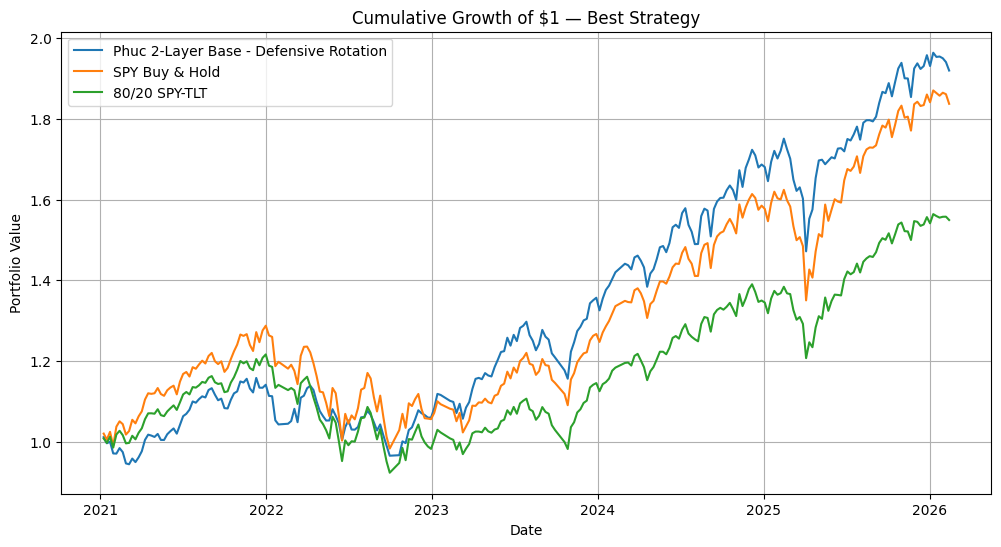

In [84]:
# Find best strategy from comparison table
best_row = strategy_only.sort_values(
    by="Sharpe Ratio", ascending=False
).iloc[0]

print("Best strategy:")
print(best_row)

best_strategy_name = best_row["Strategy"]

# Find corresponding backtest result
for test_name in results:
    for model_key in results[test_name]:
        df_res, summary = results[test_name][model_key]
        if summary.iloc[0]["Strategy"] == best_strategy_name:
            best_bt = df_res.copy()
            break

plt.figure(figsize=(12, 6))
plt.plot(best_bt.index, best_bt["strategy_growth"], label=best_strategy_name)
plt.plot(best_bt.index, best_bt["spy_growth"], label="SPY Buy & Hold")
plt.plot(best_bt.index, best_bt["growth_8020"], label="80/20 SPY-TLT")

plt.title("Cumulative Growth of $1 — Best Strategy")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.show()

Best Strategy Selected:
Strategy                 Phuc 2-Layer Base - Defensive Rotation
Annualized Return                                      0.141099
Annualized Volatility                                  0.137319
Sharpe Ratio                                           1.027525
Max Drawdown                                          -0.166579
Allocation Test                              Defensive Rotation
Model Type                                    Phuc 2-Layer Base
Name: 57, dtype: object


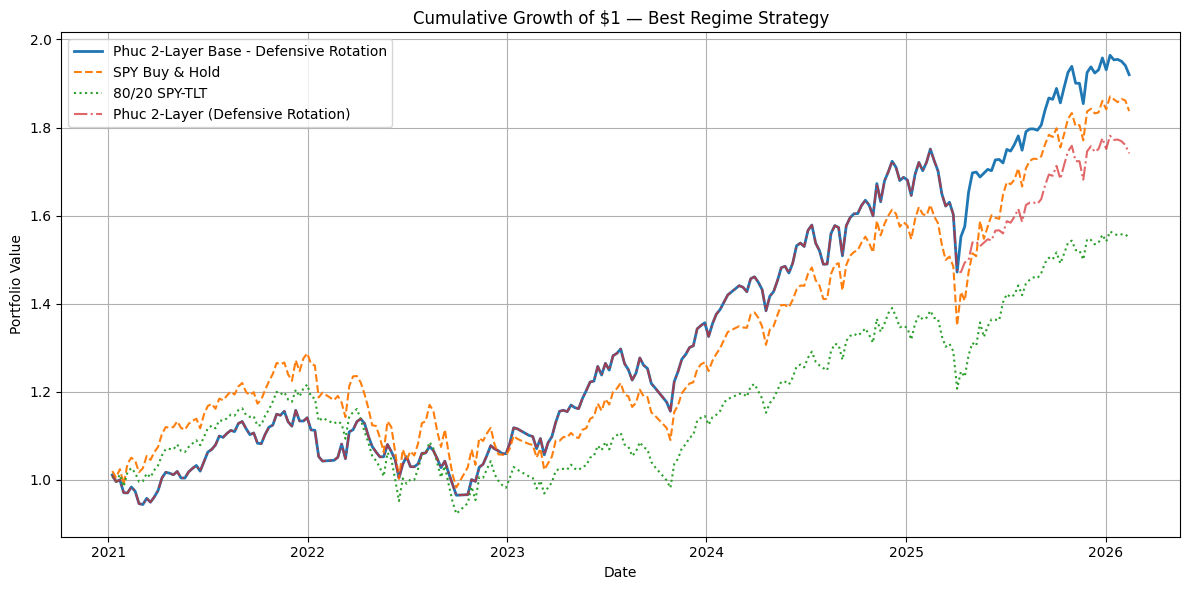

In [88]:
# Pick top-ranked strategy from sorted table
best_row = strategy_only_sorted.iloc[0]

best_strategy = best_row["Strategy"]
best_model_type = best_row["Model Type"]
best_alloc_test = best_row["Allocation Test"]

print("Best Strategy Selected:")
print(best_row)

# Map Model Type to results dictionary keys
model_key_map = {
    "Unsupervised": "unsup",
    "Persistence": "persist",
    "Arun Direct": "arun",
    "Phuc 2-Layer": "phuc",
    "Phuc 2-Layer Base": "phuc_base"
}

best_key = model_key_map[best_model_type]

# Retrieve best backtest dataframe
best_bt = results[best_alloc_test][best_key][0].copy()

# --- Plot ---
plt.figure(figsize=(12, 6))

# Best strategy (main line)
plt.plot(
    best_bt.index,
    best_bt["strategy_growth"],
    label=f"{best_strategy}",
    linewidth=2
)

# SPY benchmark
plt.plot(
    best_bt.index,
    best_bt["spy_growth"],
    label="SPY Buy & Hold",
    linestyle="--"
)

# 80/20 benchmark
plt.plot(
    best_bt.index,
    best_bt["growth_8020"],
    label="80/20 SPY-TLT",
    linestyle=":"
)

# --- Optional: Always show Phuc 2-Layer for comparison ---
if "phuc" in results.get(best_alloc_test, {}):
    phuc_bt_plot = results[best_alloc_test]["phuc"][0]
    plt.plot(
        phuc_bt_plot.index,
        phuc_bt_plot["strategy_growth"],
        label=f"Phuc 2-Layer ({best_alloc_test})",
        linestyle="-.",
        alpha=0.7
    )

# Formatting
plt.title("Cumulative Growth of $1 — Best Regime Strategy")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

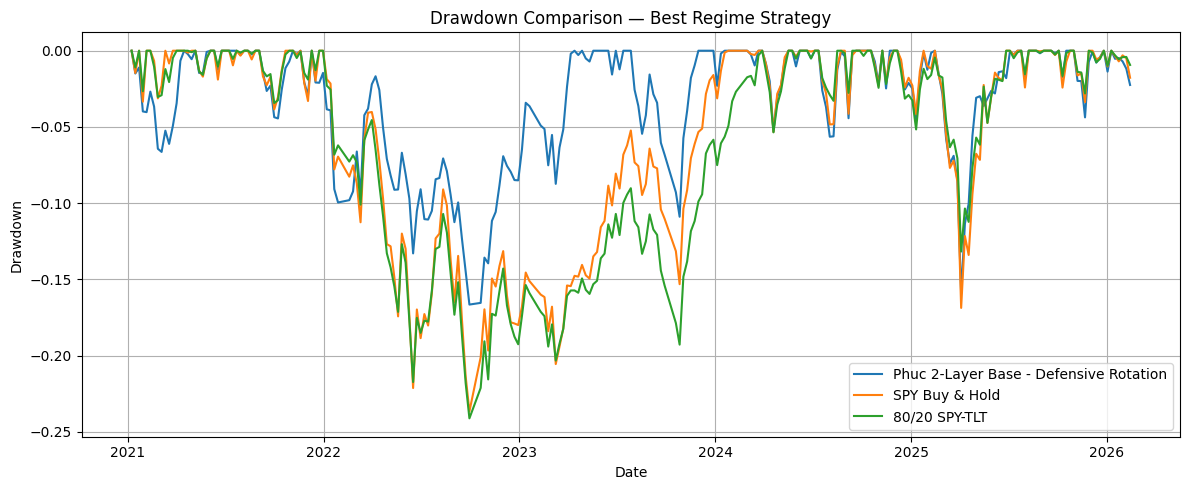

In [92]:
def compute_drawdown(return_series):
    growth = (1 + return_series.fillna(0)).cumprod()
    peak = growth.cummax()
    return growth / peak - 1

best_bt["dd_strategy"] = compute_drawdown(best_bt["strategy_return"])
best_bt["dd_spy"] = compute_drawdown(best_bt["benchmark_spy"])
best_bt["dd_8020"] = compute_drawdown(best_bt["benchmark_80_20"])

plt.figure(figsize=(12, 5))
plt.plot(best_bt.index, best_bt["dd_strategy"], label=best_strategy)
plt.plot(best_bt.index, best_bt["dd_spy"], label="SPY Buy & Hold")
plt.plot(best_bt.index, best_bt["dd_8020"], label="80/20 SPY-TLT")
plt.title("Drawdown Comparison — Best Regime Strategy")
plt.xlabel("Date")
plt.ylabel("Drawdown")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [123]:
def build_dynamic_allocation_map(
    train_df,
    regime_col,
    asset_map=None,
    top_n=10,
    expected_regimes=None,
    fallback_mode="overall"
):
    # Full asset mapping (your version)
    if asset_map is None:
        asset_map = {
            "SPY": "SP500_SPY",
            "QQQ": "NASDAQ100_QQQ",
            "TLT": "TREASURY_BOND_TLT",
            "GLD": "GOLD_GLD",
            "SLV": "SILVER_SLV",
            "USO": "CRUDE_OIL_USO",
            "XLF": "FINANCIALS_XLF",
            "XLK": "TECH_XLK",
            "XLE": "ENERGY_XLE",
            "XLY": "CONSUMER_DISCRETIONARY_XLY",
            "XLP": "CONSUMER_STAPLES_XLP",
            "XLV": "HEALTHCARE_XLV",
            "XLI": "INDUSTRIALS_XLI",
            "XLB": "MATERIALS_XLB",
            "XLU": "UTILITIES_XLU",
            "IYR": "REAL_ESTATE_IYR"
        }

    if expected_regimes is None:
        expected_regimes = ["Low_Vol", "Mid_Vol", "High_Vol"]

    # Build return column mapping
    return_cols = {asset: f"{asset}_return" for asset in asset_map.keys()}

    allocation_map = {}

    def build_weights(df_slice):
        scores = {}

        for asset, return_col in return_cols.items():
            if return_col not in df_slice.columns:
                continue

            series = df_slice[return_col].dropna()

            if len(series) < 5:
                scores[asset] = 0.0
                continue

            mean_ret = series.mean()
            vol = series.std()

            if pd.isna(vol) or vol == 0:
                score = 0.0
            else:
                score = (series.mean() * 0.7 + series.tail(4).mean() * 0.3) / vol

            scores[asset] = max(score, 0.0)

        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        selected = [(k, v) for k, v in ranked[:top_n] if v > 0]

        if not selected:
            available = [asset for asset in return_cols if return_cols[asset] in df_slice.columns][:top_n]
            if not available:
                return {}
            w = 1.0 / len(available)
            return {asset: w for asset in available}

        total_score = sum(v for _, v in selected)
        return {asset: v / total_score for asset, v in selected}

    # Build regime-specific allocations
    seen_regimes = sorted(train_df[regime_col].dropna().unique())

    for regime in seen_regimes:
        regime_slice = train_df[train_df[regime_col] == regime]
        allocation_map[regime] = build_weights(regime_slice)

    # Fallback allocation
    if fallback_mode == "overall":
        fallback_weights = build_weights(train_df)
    else:
        first_asset = list(return_cols.keys())[0]
        fallback_weights = {first_asset: 1.0}

    # Fill missing regimes
    for regime in expected_regimes:
        if regime not in allocation_map:
            allocation_map[regime] = fallback_weights.copy()

    return allocation_map

{'High_Vol': {'XLB': np.float64(0.17122081491579863), 'XLE': np.float64(0.1451221706982133), 'QQQ': np.float64(0.1430458533493609), 'XLI': np.float64(0.1423253266329908), 'SLV': np.float64(0.13795707774986576), 'XLY': np.float64(0.1329591520804679), 'SPY': np.float64(0.12736960457330276)}, 'Low_Vol': {'QQQ': np.float64(0.22925105231579973), 'XLU': np.float64(0.16651390185101034), 'XLK': np.float64(0.16587752802649297), 'XLB': np.float64(0.1339448332296203), 'SPY': np.float64(0.12198354102695838), 'XLF': np.float64(0.0948366595250877), 'USO': np.float64(0.08759248402503049)}, 'Mid_Vol': {'SLV': np.float64(0.2806191864144795), 'XLK': np.float64(0.1917638582343937), 'GLD': np.float64(0.18252923242719496), 'QQQ': np.float64(0.1459401081666351), 'SPY': np.float64(0.07365251966074526), 'USO': np.float64(0.06408143896613598), 'XLV': np.float64(0.06141365613041542)}}
                                  Strategy  Annualized Return  \
0                   Phuc 2-Layer - Dynamic             0.1470  

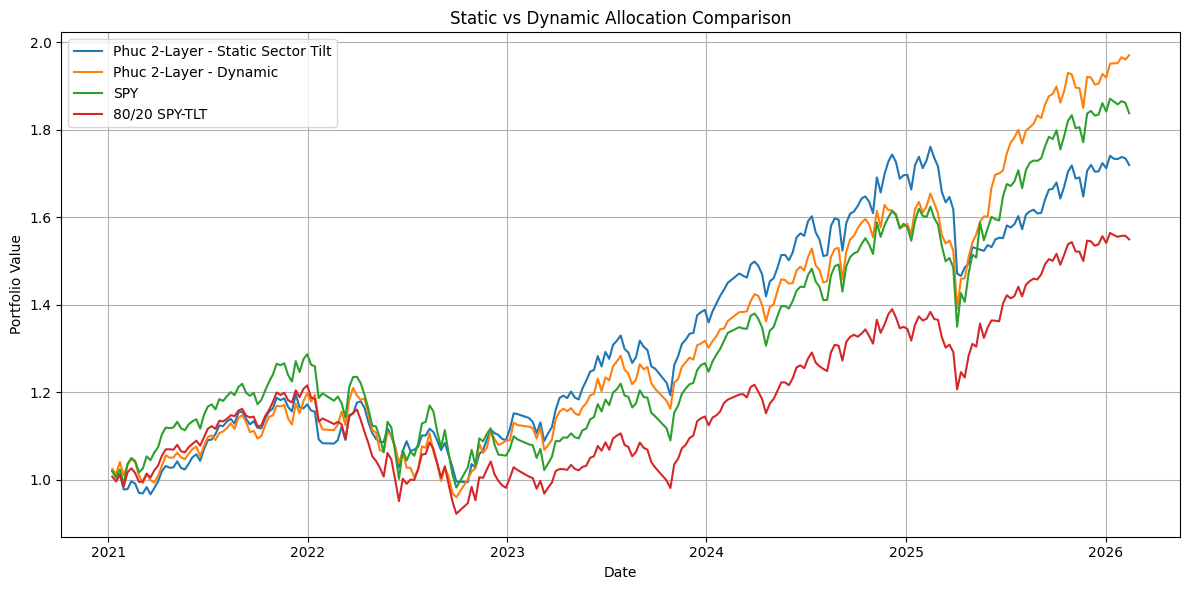

In [125]:
dynamic_map_phuc = build_dynamic_allocation_map(
    train_df=pred_val.dropna(subset=["signal_phuc_trade"]).copy(),
    regime_col="signal_phuc_trade",
    top_n=7
)

print(dynamic_map_phuc)

phuc_dynamic_res, phuc_dynamic_summary = run_allocation_backtest(
    base_df=pred_test.dropna(subset=["signal_phuc_trade"]).copy(),
    signal_col="signal_phuc_trade",
    allocation_map=dynamic_map_phuc,
    strategy_name="Phuc 2-Layer - Dynamic"
)

print(phuc_dynamic_summary.round(4))


plot_compare = pd.DataFrame()

plot_compare["Phuc 2-Layer - Static Sector Tilt"] = results["Sector Tilt"]["phuc"][0]["strategy_growth"]
plot_compare["Phuc 2-Layer - Dynamic"] = phuc_dynamic_res["strategy_growth"]
plot_compare["SPY"] = phuc_dynamic_res["spy_growth"]
plot_compare["80/20 SPY-TLT"] = phuc_dynamic_res["growth_8020"]

plot_compare = plot_compare.dropna(how="all")

plt.figure(figsize=(12, 6))
for col in plot_compare.columns:
    plt.plot(plot_compare.index, plot_compare[col], label=col)

plt.title("Static vs Dynamic Allocation Comparison")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

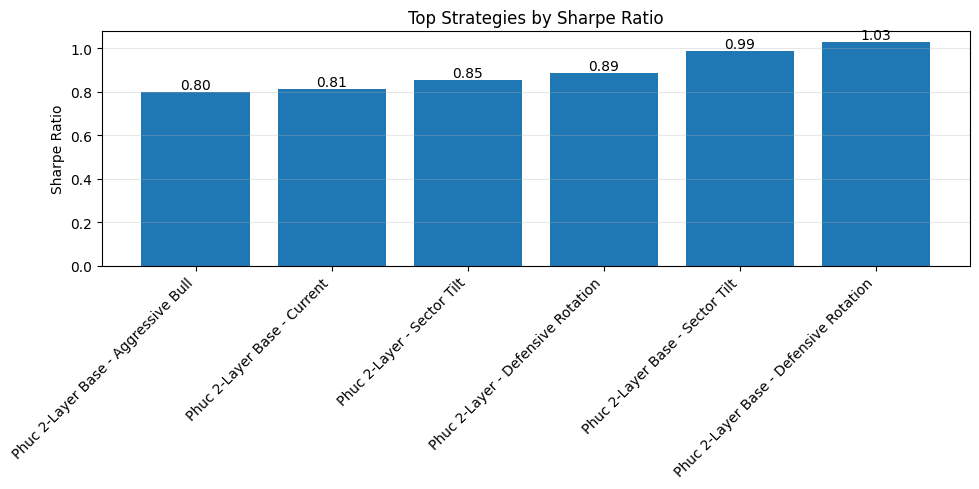

In [127]:
top_plot = strategy_only.copy().sort_values("Sharpe Ratio", ascending=False).head(6)
top_plot = top_plot.sort_values("Sharpe Ratio", ascending=True)

plt.figure(figsize=(10, 5))
bars = plt.bar(top_plot["Strategy"], top_plot["Sharpe Ratio"])

for i, v in enumerate(top_plot["Sharpe Ratio"]):
    plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')

plt.xticks(rotation=45, ha="right")
plt.title("Top Strategies by Sharpe Ratio")
plt.ylabel("Sharpe Ratio")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [131]:
# Build strategy signals directly on split data
for df in [pred_val, pred_test]:
    df["signal_persist"] = df["persistence_pred"]
    df["signal_persist_trade"] = df["signal_persist"].shift(1)

    df["signal_2l_base"] = df["phuc_2layer_base_pred"]
    df["signal_2l_base_trade"] = df["signal_2l_base"].shift(1)

    df["signal_2l"] = df["phuc_2layer_pred"]
    df["signal_2l_trade"] = df["signal_2l"].shift(1)

print("Signal columns now in pred_val:")
print([c for c in pred_val.columns if "signal" in c])

print("\nSignal columns now in pred_test:")
print([c for c in pred_test.columns if "signal" in c])

# Build dynamic allocation training/test sets from split-aware data
phuc_train = pred_val.copy()
phuc_dynamic_test = pred_test.copy()

print("Dynamic train shape:", phuc_train.shape)
print("Dynamic test shape:", phuc_dynamic_test.shape)
print("Dynamic train range:", phuc_train.index.min().date(), "to", phuc_train.index.max().date())
print("Dynamic test range:", phuc_dynamic_test.index.min().date(), "to", phuc_dynamic_test.index.max().date())

print("\nTrade signal non-null counts (train):")
print(
    phuc_train[
        ["signal_persist_trade", "signal_2l_base_trade", "signal_2l_trade"]
    ].notna().sum()
)

print("\nTrade signal non-null counts (test):")
print(
    phuc_dynamic_test[
        ["signal_persist_trade", "signal_2l_base_trade", "signal_2l_trade"]
    ].notna().sum()
)

dynamic_map_persist = build_dynamic_allocation_map(
    train_df=phuc_train.dropna(subset=["signal_persist_trade"]).copy(),
    regime_col="signal_persist_trade",
    top_n=4
)

dynamic_map_2l_base = build_dynamic_allocation_map(
    train_df=phuc_train.dropna(subset=["signal_2l_base_trade"]).copy(),
    regime_col="signal_2l_base_trade",
    top_n=4
)

dynamic_map_2l = build_dynamic_allocation_map(
    train_df=phuc_train.dropna(subset=["signal_2l_trade"]).copy(),
    regime_col="signal_2l_trade",
    top_n=4
)

print("Dynamic map - Persistence")
print(dynamic_map_persist)

print("\nDynamic map - 2L Base")
print(dynamic_map_2l_base)

print("\nDynamic map - 2L Final")
print(dynamic_map_2l)

Signal columns now in pred_val:
['signal_unsup', 'signal_unsup_trade', 'signal_persist', 'signal_persist_trade', 'signal_arun', 'signal_arun_trade', 'signal_phuc', 'signal_phuc_trade', 'signal_phuc_base', 'signal_phuc_base_trade', 'signal_2l_base', 'signal_2l_base_trade', 'signal_2l', 'signal_2l_trade']

Signal columns now in pred_test:
['signal_unsup', 'signal_unsup_trade', 'signal_persist', 'signal_persist_trade', 'signal_arun', 'signal_arun_trade', 'signal_phuc', 'signal_phuc_trade', 'signal_phuc_base', 'signal_phuc_base_trade', 'signal_2l_base', 'signal_2l_base_trade', 'signal_2l', 'signal_2l_trade']
Dynamic train shape: (196, 96)
Dynamic test shape: (258, 96)
Dynamic train range: 2017-01-13 to 2020-12-25
Dynamic test range: 2021-01-01 to 2026-02-13

Trade signal non-null counts (train):
signal_persist_trade    195
signal_2l_base_trade    195
signal_2l_trade         195
dtype: int64

Trade signal non-null counts (test):
signal_persist_trade    257
signal_2l_base_trade    257
signal

In [139]:
available_asset_map = {
    "SPY": "SP500_SPY",
    "QQQ": "NASDAQ100_QQQ",
    "TLT": "TREASURY_BOND_TLT",
    "GLD": "GOLD_GLD",
    "SLV": "SILVER_SLV",
    "USO": "CRUDE_OIL_USO",
    "XLF": "FINANCIALS_XLF",
    "XLK": "TECH_XLK",
    "XLE": "ENERGY_XLE",
    "XLY": "CONSUMER_DISCRETIONARY_XLY",
    "XLP": "CONSUMER_STAPLES_XLP",
    "XLV": "HEALTHCARE_XLV",
    "XLI": "INDUSTRIALS_XLI",
    "XLB": "MATERIALS_XLB",
    "XLU": "UTILITIES_XLU",
    "IYR": "REAL_ESTATE_IYR"
}

dynamic_map_persist = build_dynamic_allocation_map(
    train_df=phuc_train.dropna(subset=["signal_persist_trade"]).copy(),
    regime_col="signal_persist_trade",
    asset_map=available_asset_map,
    top_n=10,
    expected_regimes=["Low_Vol", "Mid_Vol", "High_Vol"]
)

dynamic_map_2l_base = build_dynamic_allocation_map(
    train_df=phuc_train.dropna(subset=["signal_2l_base_trade"]).copy(),
    regime_col="signal_2l_base_trade",
    asset_map=available_asset_map,
    top_n=10,
    expected_regimes=["Low_Vol", "Mid_Vol", "High_Vol"]
)

dynamic_map_2l = build_dynamic_allocation_map(
    train_df=phuc_train.dropna(subset=["signal_2l_trade"]).copy(),
    regime_col="signal_2l_trade",
    asset_map=available_asset_map,
    top_n=10,
    expected_regimes=["Low_Vol", "Mid_Vol", "High_Vol"]
)

def allocation_map_to_df(allocation_map, name):
    rows = []
    for regime, weights in allocation_map.items():
        row = {"Strategy": name, "Regime": regime}
        row.update(weights)
        rows.append(row)
    return pd.DataFrame(rows)

df_persist = allocation_map_to_df(dynamic_map_persist, "Persistence")
df_2l_base = allocation_map_to_df(dynamic_map_2l_base, "2L Base")
df_2l = allocation_map_to_df(dynamic_map_2l, "2L Final")

dynamic_map_df = pd.concat([df_persist, df_2l_base, df_2l], ignore_index=True)

# Fill missing assets with 0
dynamic_map_df = dynamic_map_df.fillna(0)

# Order columns nicely
asset_order = list(available_asset_map.keys())
cols = ["Strategy", "Regime"] + [c for c in asset_order if c in dynamic_map_df.columns]
dynamic_map_df = dynamic_map_df[cols]

print(dynamic_map_df.round(3))

      Strategy    Regime    SPY    QQQ    GLD    SLV    USO    XLF    XLK  \
0  Persistence  High_Vol  0.092  0.114  0.000  0.095  0.000  0.083  0.090   
1  Persistence   Low_Vol  0.028  0.196  0.000  0.000  0.000  0.000  0.064   
2  Persistence   Mid_Vol  0.066  0.124  0.170  0.231  0.105  0.022  0.153   
3      2L Base  High_Vol  0.088  0.098  0.059  0.104  0.000  0.097  0.081   
4      2L Base   Low_Vol  0.102  0.180  0.000  0.000  0.061  0.074  0.134   
5      2L Base   Mid_Vol  0.069  0.132  0.166  0.252  0.054  0.021  0.176   
6     2L Final  High_Vol  0.094  0.105  0.000  0.102  0.000  0.092  0.091   
7     2L Final   Low_Vol  0.098  0.184  0.000  0.000  0.070  0.076  0.133   
8     2L Final   Mid_Vol  0.067  0.133  0.167  0.257  0.059  0.019  0.175   

     XLE    XLY    XLV    XLI    XLB    XLU  
0  0.128  0.112  0.071  0.100  0.114  0.000  
1  0.000  0.000  0.019  0.000  0.125  0.568  
2  0.000  0.043  0.060  0.000  0.026  0.000  
3  0.135  0.103  0.000  0.105  0.129  0.000  

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=059a5e93-4459-411b-9a58-2a578fd7a892' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>